<a href="https://colab.research.google.com/github/rithishdev/DL_Lab/blob/main/DL_Exp06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Part A: Dataset Preparation and Text Preprocessing

In [1]:
import numpy as np
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# 1. Load the IMDB dataset
num_words = 10000
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=num_words)

word_index = imdb.get_word_index()
reverse_word_index = {value: key for key, value in word_index.items()}

def decode_review(encoded_review):
    return ' '.join([reverse_word_index.get(i - 3, '?') for i in encoded_review])

sample_review = decode_review(X_train[0])
print("Sample Positive Review:\n", sample_review[:500], "...")
print("Sentiment Label (1=Positive, 0=Negative):", y_train[0])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step
Sample Positive Review:
 ? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to ever ...
Sentiment Label (1=Positive, 0=Negative): 1


In [2]:
def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove special characters and punctuation
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Tokenize and remove stop words
    tokens = text.split()
    filtered_tokens = [w for w in tokens if w not in stop_words and w != '?']
    return " ".join(filtered_tokens)

decoded_reviews = [decode_review(seq) for seq in X_train[:500]]
cleaned_reviews = [preprocess_text(review) for review in decoded_reviews]

print("Original decoded:", decoded_reviews[0][:150])
print("Cleaned:", cleaned_reviews[0][:150])

Original decoded: ? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being
Cleaned: film brilliant casting location scenery story direction everyones really suited part played could imagine robert amazing actor director father came sc


In [3]:
# 2. Tokenize, build vocabulary, and pad sequences
max_length = 150 # Max sequence length

# Pad sequences to ensure uniform length
X_train_padded = pad_sequences(X_train, maxlen=max_length, padding='post', truncating='post')
X_test_padded = pad_sequences(X_test, maxlen=max_length, padding='post', truncating='post')

print("Shape of training tensor:", X_train_padded.shape)
print("Shape of testing tensor:", X_test_padded.shape)

Shape of training tensor: (25000, 150)
Shape of testing tensor: (25000, 150)


### Part B: Embedding Generation

In [4]:
from tensorflow.keras.layers import Embedding

embedding_dim = 128

# Create an embedding layer instance
embedding_layer = Embedding(input_dim=num_words, output_dim=embedding_dim, input_length=max_length)

# Display embedding representation characteristics
print(f"Vocabulary Size (Input Dim): {num_words}")
print(f"Embedding Dimension (Output Dim): {embedding_dim}")
print(f"Input Sequence Length: {max_length}")

Vocabulary Size (Input Dim): 10000
Embedding Dimension (Output Dim): 128
Input Sequence Length: 150


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [11]:
# Pass some padded sequences through the embedding layer to show the shape and vector representation
sample_batch = X_train_padded[:2]
embedding_output = embedding_layer(sample_batch)

print("Input shape:", sample_batch.shape)
print("Output embedding shape:", embedding_output.shape)
print("Sample vector representation of the first word in the first review:\n", embedding_output[0, 0, :10].numpy(), "...")

Input shape: (2, 150)
Output embedding shape: (2, 150, 128)
Sample vector representation of the first word in the first review:
 [-0.0074651  -0.0454011   0.02093804  0.04678922  0.04753962 -0.03171015
  0.01764197  0.02670452  0.0268716   0.02074542] ...


### Part C: Implementing the LSTM Model

In [12]:
# Build the Sequential model explicitly with an Input layer to display parameter counts
model = Sequential([
    tf.keras.Input(shape=(max_length,)),
    Embedding(input_dim=num_words, output_dim=embedding_dim),
    LSTM(128, dropout=0.2, recurrent_dropout=0.2),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 150, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,411,713 (5.39 MB)

 Trainable params: 1,411,713 (5.39 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Build the LSTM model architecture
model = Sequential([
    Embedding(input_dim=num_words, output_dim=embedding_dim),
    LSTM(128, dropout=0.2, recurrent_dropout=0.2),
    Dense(1, activation='sigmoid')
])

# Compile the model with appropriate parameters
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display the architecture summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Part D: Model Training and Sentiment Prediction

In [6]:
# Train the model
epochs = 3
batch_size = 64

history = model.fit(
    X_train_padded, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.2,
    verbose=1
)

Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 168s 521ms/step - accuracy: 0.6219 - loss: 0.6470 - val_accuracy: 0.6652 - val_loss: 0.6305
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 167s 534ms/step - accuracy: 0.7179 - loss: 0.5747 - val_accuracy: 0.6780 - val_loss: 0.6190
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 164s 526ms/step - accuracy: 0.7207 - loss: 0.5635 - val_accuracy: 0.7154 - val_loss: 0.5844


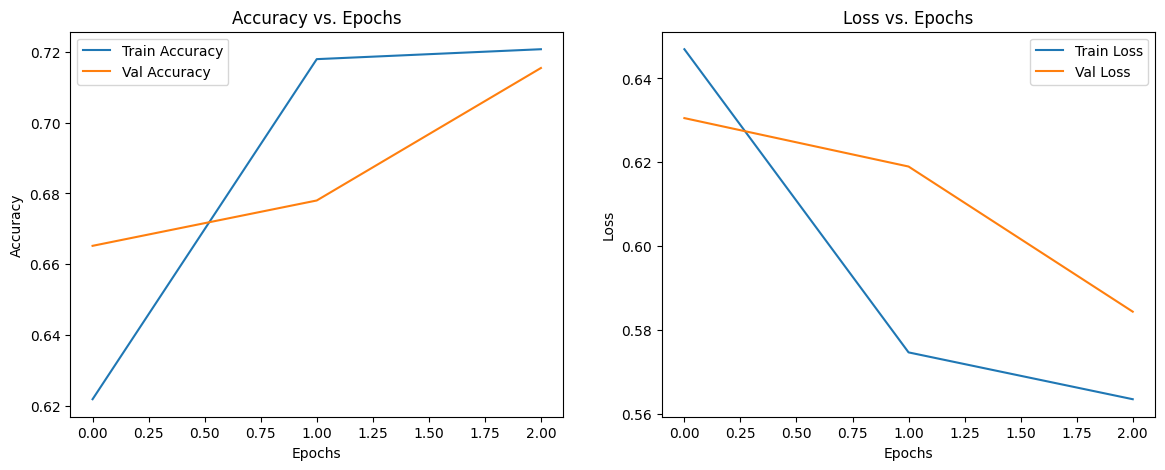

In [7]:
# Visualize Accuracy and Loss vs Epochs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot accuracy
ax1.plot(history.history['accuracy'], label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
ax1.set_title('Accuracy vs. Epochs')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()

# Plot loss
ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_title('Loss vs. Epochs')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()

plt.show()

Test Loss: 0.5913
Test Accuracy: 0.7101
782/782 ━━━━━━━━━━━━━━━━━━━━ 49s 62ms/step
Precision: 0.8258
Recall: 0.5325
F1-Score: 0.6475


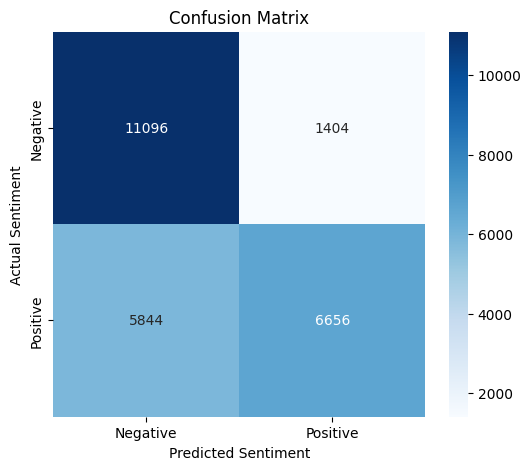

In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns

# Evaluate the model on test dataset
test_loss, test_accuracy = model.evaluate(X_test_padded, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Predict probabilities and convert to binary classes
y_pred_prob = model.predict(X_test_padded)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Calculate evaluation metrics
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.show()

In [13]:
# Predict and compare sample reviews
sentiment_map = {0: "Negative", 1: "Positive"}

print("=== Sample Sentiment Predictions ===\n")
for i in range(5):
    decoded = decode_review(X_test[i])
    actual_label = y_test[i]

    # Reshape for single prediction
    single_padded = X_test_padded[i:i+1]
    pred_prob = model.predict(single_padded, verbose=0)[0][0]
    pred_label = 1 if pred_prob > 0.5 else 0

    print(f"Review #{i+1}:")
    print(f"Content: {decoded[:200]}...")
    print(f"Actual Sentiment: {sentiment_map[actual_label]}")
    print(f"Predicted Sentiment: {sentiment_map[pred_label]} (Probability: {pred_prob:.4f})")
    print("-" * 50)

=== Sample Sentiment Predictions ===

Review #1:
Content: ? please give this one a miss br br ? ? and the rest of the cast rendered terrible performances the show is flat flat flat br br i don't know how michael madison could have allowed this one on his pla...
Actual Sentiment: Negative
Predicted Sentiment: Positive (Probability: 0.5019)
--------------------------------------------------
Review #2:
Content: ? this film requires a lot of patience because it focuses on mood and character development the plot is very simple and many of the scenes take place on the same set in frances ? the sandy dennis char...
Actual Sentiment: Positive
Predicted Sentiment: Positive (Probability: 0.5040)
--------------------------------------------------
Review #3:
Content: ? many animation buffs consider ? ? the great forgotten genius of one special branch of the art puppet animation which he invented almost single ? and as it happened almost accidentally as a young man...
Actual Sentiment: Positive
Pre